# Actividad 7: Iterative Policy Evaluation
## Héctor Arturo Hernández Escalante
### Profesor: Dr. Victor Uc
### Maestría en Ciencias de la Computación
### Segundo Semestre
### Universidad Autónoma de Yucatán
### 20 de Mayo 2026


### 1. Introduction
Iterative Policy Evaluation is an algorithm used to compute the state-value function $V^\pi$ for an arbitrary policy $\pi$. It is a fundamental component of Policy Iteration.

In this activity, we implement the algorithm for a $4 \times 4$ Gridworld environment, similar to the one described in Example 4.1 of Sutton & Barto's "Reinforcement Learning: An Introduction".

The update rule is based on the Bellman equation:
$V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s', r} p(s', r | s, a) [r + \gamma V_k(s')]$


### 2. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 3. Gridworld Environment
We define a $4 \times 4$ grid where the top-left and bottom-right cells are terminal states. Every transition results in a reward of -1.

In [2]:
class GridWorld:
    def __init__(self, size=4):
        self.size = size
        self.states = [(i, j) for i in range(size) for j in range(size)]
        self.terminal_states = [(0, 0), (size - 1, size - 1)]
        self.actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # Up, Down, Left, Right
    
    def step(self, state, action):
        if state in self.terminal_states:
            return state, 0
        
        next_state = (state[0] + action[0], state[1] + action[1])
        
        # Check boundaries
        if not (0 <= next_state[0] < self.size and 0 <= next_state[1] < self.size):
            next_state = state
            
        return next_state, -1


### 4. Iterative Policy Evaluation Implementation

In [3]:
def iterative_policy_evaluation(env, policy, gamma=1.0, theta=1e-4):
    """
    Computes the value function V for a given policy using iterative updates.
    """
    V = np.zeros((env.size, env.size))
    
    while True:
        delta = 0
        new_V = np.copy(V)
        for i, j in env.states:
            if (i, j) in env.terminal_states:
                continue
                
            v = 0
            for action_idx, action in enumerate(env.actions):
                prob = policy[i, j, action_idx]
                next_state, reward = env.step((i, j), action)
                v += prob * (reward + gamma * V[next_state[0], next_state[1]])
            
            new_V[i, j] = v
            delta = max(delta, abs(V[i, j] - new_V[i, j]))
        
        V = new_V
        if delta < theta:
            break
            
    return V


### 5. Execution and Visualization
We evaluate a uniform random policy where $\pi(a|s) = 0.25$ for all $a, s$.

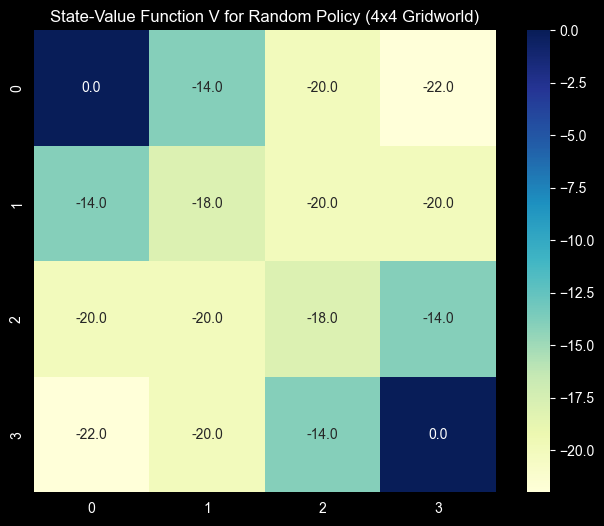

In [4]:
# Initialize environment
env = GridWorld(size=4)

# Define uniform random policy: 4 actions, equal probability
policy = np.ones((env.size, env.size, len(env.actions))) * 0.25

# Run evaluation
V = iterative_policy_evaluation(env, policy)

# Round for better display
V_rounded = np.round(V, 1)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(V, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True, square=True)
plt.title("State-Value Function V for Random Policy (4x4 Gridworld)")
plt.show()


### 6. Analysis
The resulting value function shows the expected values for a random walk in a $4 \times 4$ grid. 
- The terminal states have a value of **0.0**.
- States adjacent to terminal states have higher values (e.g., -14.0) compared to the central states (e.g., -22.0), reflecting the average number of steps required to reach a terminal state under a random policy.
- The symmetry of the grid is preserved in the computed values.
